# Metric calculation and heatmap plotting


Compute per-model fit metrics (CCC, RMSE, MAE, Bias vs. experimental growth) from each
experiment's `*_results.csv` (written by `03_simulations.ipynb`) and save them alongside as
`*_metrics.csv` in `../results/tables/`.

In [1]:
import os

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Canonical model order used throughout the manuscript
MODEL_ORDER = ["iYO844", "iBsu1147", "eciYO844", "iBB1018", "iBsu1147R", "ecBSU1", "Submodel"]

# One colour per model, same assignment as 05/07 so a model keeps its colour across every figure.
MODEL_COLORS = {
    "iYO844": "#2a78d6", "iBsu1147": "#eb6834", "eciYO844": "#1baf7a", "iBB1018": "#eda100",
    "iBsu1147R": "#e87ba4", "ecBSU1": "#008300", "Submodel": "#4a3aa7",
}
MUTED, GRID_COLOR = "#52514e", "#e1e0d9"

# Columns in the *_results.csv that describe the condition rather than a model's prediction.
METADATA_COLUMNS = ["condition", "reactions", "import fluxes", "experimental growth"]

EXPERIMENTS = {
    "Chubukov_2013": "Chubukov 2013",
    "Dauner_2001": "Dauner 2001",
    "Dauner_2001caa3KO": r"Dauner 2001, $caa_3$ KO",
}


def concordance_correlation_coefficient(y_true, y_pred):
    """Lin's concordance correlation coefficient. Same implementation as 07_fluxes.ipynb."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    if len(y_true) < 2 or np.ptp(y_true) == 0 or np.ptp(y_pred) == 0:
        return np.nan          # correlation undefined for a constant series
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    r, _ = pearsonr(y_true, y_pred)
    return (2 * r * sd_true * sd_pred) / (var_true + var_pred + (mean_true - mean_pred) ** 2)


def calculate_metrics(results_csv, exp_col="experimental growth", model_cols=None):
    """Fit metrics for one experiment's results CSV; writes a sibling `*_metrics.csv`.

    `model_cols` defaults to MODEL_ORDER, not to every non-experimental column: the older default
    scored `condition`, `reactions` and `import fluxes` as if they were models.
    """
    df = pd.read_csv(results_csv)

    df[exp_col] = pd.to_numeric(df[exp_col], errors="coerce")
    df = df.dropna(subset=[exp_col])

    if model_cols is None:
        model_cols = [m for m in MODEL_ORDER if m in df.columns]

    experimental = df[exp_col]
    results = []

    for model in model_cols:
        predicted = pd.to_numeric(df[model], errors="coerce")
        valid_mask = ~(predicted.isna() | experimental.isna())
        y_true = experimental[valid_mask]
        y_pred = predicted[valid_mask]

        if len(y_true) == 0:
            rmse = mae = bias = ccc = np.nan
        else:
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            bias = np.mean(y_pred - y_true)
            ccc = concordance_correlation_coefficient(y_true, y_pred)

        results.append({
            "Model": model,
            # Conditions actually scored; an infeasible solve reduces it for that model.
            "n": int(valid_mask.sum()),
            "n_total": len(experimental),
            "CCC": ccc,
            "RMSE": rmse,
            "MAE": mae,
            "Bias": bias,
        })

    metrics_df = pd.DataFrame(results)

    metrics_csv = results_csv.replace("_results.csv", "_metrics.csv")
    metrics_df.to_csv(metrics_csv, index=False)
    print(f"[INFO] metrics written to {metrics_csv}")
    dropped = metrics_df[metrics_df["n"] < metrics_df["n_total"]]
    for row in dropped.itertuples():
        print(f"       note: {row.Model} scored on {row.n} of {row.n_total} conditions "
              f"(infeasible solve elsewhere)")

    return metrics_df

Clustered heatmap of each model's relative error per condition.

In [2]:
MISSING_COLOR = "#c9c8c1"


def heatmap_clustered(results_csv, output_file):
    """Clustered relative-error heatmap, one column per model, annotated with its CCC.

    The label used to be the mean signed error, a bias rather than an accuracy score: it let
    over- and under-predictions cancel and ranked iYO844 first on 0.002 while its mean absolute
    error was the worst of the top three.
    """
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial']
    # Math in labels ($\mu$, h$^{-1}$) otherwise renders in matplotlib's default DejaVu while
    # the surrounding text is Arial, so one axis label ends up in two typefaces.
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.rm'] = 'Arial'
    plt.rcParams['mathtext.it'] = 'Arial:italic'
    plt.rcParams['mathtext.bf'] = 'Arial:bold'

    df = pd.read_csv(results_csv)
    experimental = df["experimental growth"]

    error_df = pd.DataFrame()
    for model in MODEL_ORDER:
        error_df[model] = (df[model] - experimental) / experimental
    error_df.index = df["condition"] + "___" + df["import fluxes"].astype(str)

    ccc_by_model = {
        model: concordance_correlation_coefficient(
            experimental[df[model].notna()], df[model].dropna())
        for model in MODEL_ORDER
    }

    # Best first; clustering reorders afterwards, this only makes the input deterministic.
    ranking = pd.Series(ccc_by_model).sort_values(ascending=False)
    error_df = error_df[ranking.index]

    # An infeasible solve is a failure to grow, so it clusters at -1 rather than +1; it is then
    # over-painted grey so it is not read as a computed value either way.
    missing = ~np.isfinite(error_df)
    error_df_clipped = error_df.mask(missing).clip(upper=1, lower=-1).fillna(-1)

    annot = error_df_clipped.map(lambda v: f"{v:.2f}").mask(missing, "n/a")

    g = sns.clustermap(
        error_df_clipped,
        row_cluster=True,
        col_cluster=True,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        annot=annot.to_numpy(),
        fmt="",
        annot_kws={"fontsize": 16},
        linewidths=0.5,
        figsize=(12, 8),
        cbar_kws={"label": "Relative Error"},
        xticklabels=False,
        yticklabels=False
    )

    ax = g.ax_heatmap
    row_order = g.dendrogram_row.reordered_ind
    col_order = g.dendrogram_col.reordered_ind

    # Grey out the infeasible cells, in the clustered order the heatmap is actually drawn in.
    missing_ordered = missing.iloc[row_order, :].iloc[:, col_order]
    for i in range(missing_ordered.shape[0]):
        for j in range(missing_ordered.shape[1]):
            if missing_ordered.iat[i, j]:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=MISSING_COLOR,
                                           edgecolor="white", linewidth=0.5, zorder=3))
                ax.text(j + 0.5, i + 0.5, "n/a", ha="center", va="center",
                        fontsize=14, color="#3d3c39", zorder=4)

    ax.set_xticks(np.arange(len(error_df.columns)) + 0.5)
    ax.set_xticklabels(
        [
            f"{error_df.columns[col_order[i]]}\n({ranking[error_df.columns[col_order[i]]]:.2f})"
            for i in range(len(error_df.columns))
        ],
        rotation=45,
        ha="center",
        fontsize=13
    )

    yticks_labels = []
    for idx in row_order:
        label = error_df.index[idx]
        condition, flux = label.split("___")
        yticks_labels.append(f"{condition}\n({flux})")

    ax.set_yticks(np.arange(len(error_df.index)) + 0.5)
    ax.set_yticklabels(yticks_labels, fontsize=11)

    ax.set_xlabel("Models", fontsize=15)
    ax.set_ylabel("Conditions", fontsize=15)

    g.ax_cbar.tick_params(labelsize=12)
    g.ax_cbar.yaxis.label.set_size(13)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.close()

    return output_file

## Fit-metric figure (supplementary)

The heatmaps show the per-condition error; this shows the two summary statistics that carry the
interpretation, for every model and all three experiments at once.

- **CCC** is the headline: agreement with the 1:1 line, penalising systematic offset and scale
  error rather than just scatter. Same statistic as the flux analysis in `07_fluxes.ipynb`.
- **Bias** is signed, and is a *diagnostic rather than a score* - it can sit at zero while a model
  is badly wrong, because over- and under-predictions cancel. That is exactly what made it the
  wrong choice for the heatmap's per-model label. Its value here is the sign pattern: every model
  underestimates on the carbon sources and overestimates on the chemostat series.

RMSE and MAE are still computed into `*_metrics.csv` but are no longer plotted. On this data they
track CCC closely and their ratio is near-constant across models (1.1-1.2 everywhere), so neither
the magnitude nor the spread of the error added a reading that CCC did not already give.

In [3]:
def plot_growth_metrics(all_metrics, output_file):
    """2x2 grid of the fit metrics, grouped by experiment, one bar per model."""
    plt.rcParams.update({
        "font.size": 13,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial"],
        # Math in labels ($\mu$, h$^{-1}$) otherwise renders in matplotlib's default DejaVu while
        # the surrounding text is Arial, so one axis label ends up in two typefaces.
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
        "axes.labelsize": 14,
        "axes.titlesize": 15,
        "legend.fontsize": 13,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#c3c2b7",
        "pdf.fonttype": 42,
    })

    # CCC and Bias only. RMSE and MAE track CCC closely here, so plotting them added no reading.
    panels = [
        ("CCC", "Concordance correlation coefficient", "Agreement (higher is better)"),
        ("Bias", r"Bias (h$^{-1}$)", "Direction of error - diagnostic, not a score"),
    ]
    experiments = list(EXPERIMENTS)
    x = np.arange(len(experiments))
    slot = 0.84 / len(MODEL_ORDER)
    bar_width = slot * 0.86

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

    for panel_letter, (ax, (metric, ylabel, subtitle)) in zip("AB", zip(axes.ravel(), panels)):
        for i, model in enumerate(MODEL_ORDER):
            values = [all_metrics[(experiment, model)][metric] for experiment in experiments]
            offset = (i - (len(MODEL_ORDER) - 1) / 2) * slot
            ax.bar(x + offset, values, bar_width, label=model, color=MODEL_COLORS[model],
                   linewidth=0, zorder=3)

        ax.axhline(0, color="#c3c2b7", linewidth=1.2, zorder=4)
        ax.set_ylabel(ylabel)
        ax.set_title(subtitle, fontweight="bold", fontsize=13)
        ax.set_xticks(x)
        ax.set_xticklabels([EXPERIMENTS[e] for e in experiments], fontsize=12)
        ax.set_xlim(-0.6, len(experiments) - 0.4)
        ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        ax.tick_params(colors=MUTED)
        ax.yaxis.label.set_color(MUTED)
        for label in ax.get_xticklabels():
            label.set_color("#0b0b0b")
        ax.text(-0.11, 1.06, panel_letter, transform=ax.transAxes, fontfamily="Arial",
                fontsize=20, fontweight="bold", ha="left", va="bottom", color="#0b0b0b")

    # CCC is bounded above by 1; let it dip below zero if a model is anti-correlated.
    axes.ravel()[0].set_ylim(min(0, axes.ravel()[0].get_ylim()[0]), 1.0)

    fig.tight_layout(w_pad=2.5)
    fig.subplots_adjust(bottom=0.22)
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.01), frameon=False,
               ncol=4)

    plt.savefig(output_file, bbox_inches="tight")
    plt.show()
    print(f"[INFO] Figure saved to {output_file}")
    return output_file

## Run

[INFO] metrics written to ../results/tables\Chubukov_2013_metrics.csv
       note: iBsu1147 scored on 7 of 8 conditions (infeasible solve elsewhere)


[INFO] metrics written to ../results/tables\Dauner_2001_metrics.csv


[INFO] metrics written to ../results/tables\Dauner_2001caa3KO_metrics.csv


[INFO] combined metrics written to ../results/tables\growth_metrics_all_experiments.csv

CCC per model and experiment (higher is better):
Experiment  Chubukov_2013  Dauner_2001  Dauner_2001caa3KO
Model                                                    
iYO844              0.903        0.876              0.973
iBsu1147            0.750        0.878              0.878
eciYO844            0.333        0.886              0.964
iBB1018             0.909        0.855              0.973
iBsu1147R           0.845        0.894              0.982
ecBSU1              0.845        0.894              0.982
Submodel            0.898        0.788              0.975


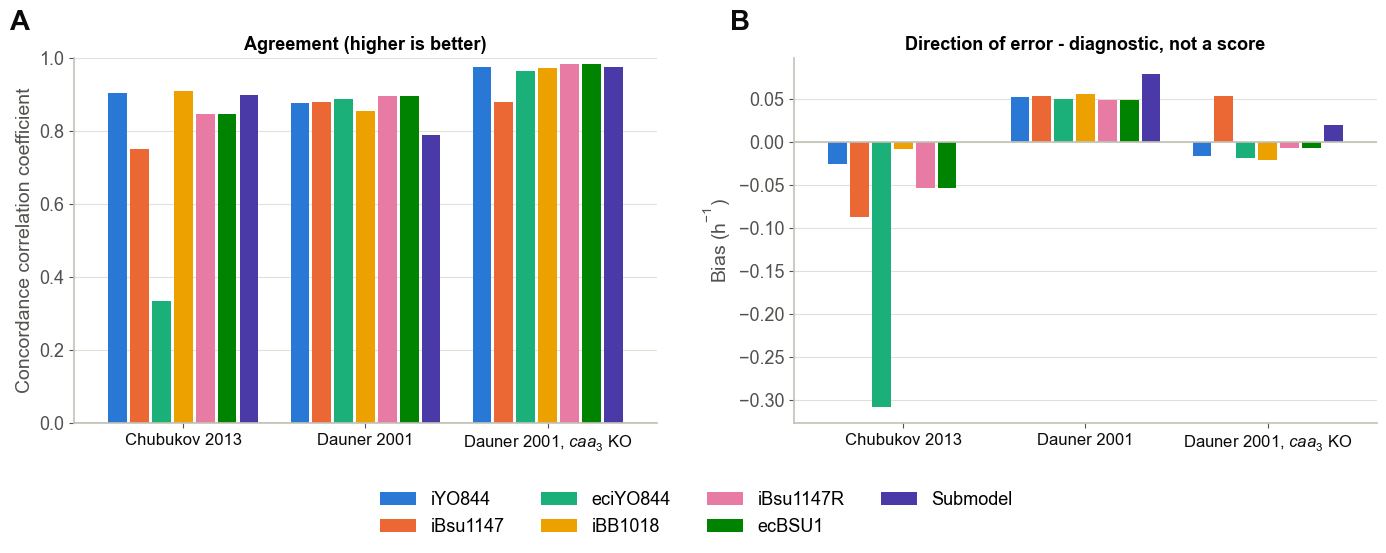

[INFO] Figure saved to ../results/figures\Plot_growth_fit_metrics.pdf


'../results/figures\\Plot_growth_fit_metrics.pdf'

In [4]:
figures_dir = "../results/figures"
tables_dir = "../results/tables"
os.makedirs(figures_dir, exist_ok=True)

# 03_simulations writes one <experiment>_results.csv per experiment into results/tables/
all_metrics = {}
for experiment in EXPERIMENTS:
    results_csv = os.path.join(tables_dir, f"{experiment}_results.csv")
    metrics = calculate_metrics(results_csv)
    for row in metrics.itertuples():
        all_metrics[(experiment, row.Model)] = {"CCC": row.CCC, "RMSE": row.RMSE,
                                                "MAE": row.MAE, "Bias": row.Bias}
    heatmap_clustered(results_csv, os.path.join(figures_dir, f"Heatmap_{experiment}_results.pdf"))

# One tidy long-form table across all three experiments, for the manuscript summary table.
combined = pd.DataFrame(
    [{"Experiment": experiment, "Model": model, **values}
     for (experiment, model), values in all_metrics.items()]
)
combined_path = os.path.join(tables_dir, "growth_metrics_all_experiments.csv")
combined.to_csv(combined_path, index=False)
print(f"[INFO] combined metrics written to {combined_path}\n")

print("CCC per model and experiment (higher is better):")
print(combined.pivot(index="Model", columns="Experiment", values="CCC")
      .loc[MODEL_ORDER, list(EXPERIMENTS)].round(3).to_string())

plot_growth_metrics(all_metrics, os.path.join(figures_dir, "Plot_growth_fit_metrics.pdf"))